# OOS cyclostationary linear–TCNN model with variability-aware loss

This version still predicts the **next 11-dimensional state directly**:

\[
\widehat{\mathbf{x}}_{t+1}
=
A(m_{t+1})\mathbf{x}_t
+
g_{\mathrm{TCNN}}
\left(
G\mathbf{x}_{t-11:t},
m_{t+1}
\right)
\]

The model architecture is unchanged, but the training objective now
penalizes four different errors:

\[
\mathcal{L}
=
\lambda_{\mathrm{state}}\mathcal{L}_{\mathrm{state}}
+
\lambda_{\mathrm{corr}}\mathcal{L}_{\mathrm{corr}}
+
\lambda_{\Delta}\mathcal{L}_{\Delta}
+
\lambda_{\mathrm{var}}\mathcal{L}_{\mathrm{var}}
+
\lambda_{\mathrm{gate}}\mathcal{L}_{\mathrm{gate}}.
\]

- **State loss** keeps the complete predicted state close to observations.
- **Correlation loss** trains the 3-month-mean PP forecast pattern directly.
- **Increment loss** trains month-to-month PP changes and turning behaviour.
- **Variance loss** penalizes excessive collapse of forecast amplitude.
- **Gate penalty** remains a small regularization term.

The output target is still the next state, not \(dx/dt\). Differences and
variance are used only as auxiliary training losses.


In [1]:
# Blocked-jackknife OOS LSTM test for Regions 9, 10, and 11

from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# Settings
# ============================================================

STATE_VECTOR_FILE = (
    "data_input/"
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_"
    "RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)
STATE_VECTOR_VARIABLE = "state_vector"

TEST_REGIONS = [9, 10, 11]

LOOKBACK = 12
TRAIN_HORIZON = 6
MAX_LEAD = 24

# ------------------------------------------------------------
# Cyclostationary linear pathway
# ------------------------------------------------------------

SEASONAL_RANK = 2

USE_ANNUAL_CYCLE = True
USE_SEMIANNUAL_CYCLE = False

# ------------------------------------------------------------
# Depthwise-separable temporal CNN
# ------------------------------------------------------------

CNN_HIDDEN_CHANNELS = 4
CNN_KERNEL_SIZE = 3

# Causal dilations 1, 2, and 4 give a 15-month theoretical
# receptive field. With LOOKBACK=12, the final feature can use
# the complete available history.
CNN_DILATIONS = (1, 2, 4)

CNN_LATENT_SIZE = 4

# ------------------------------------------------------------
# Soft variable gate
# ------------------------------------------------------------

# Gates begin mostly open. PP is always fixed to exactly 1.
GATE_INITIAL_VALUE = 0.90

# Slight pressure toward smaller non-PP gates.
# Compare with 0.0 to quantify the effect of the sparsity pressure.
GATE_L1_LAMBDA = 1e-3

# ------------------------------------------------------------
# Optimization
# ------------------------------------------------------------

N_EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

# The mean linear operator starts as identity. Weight decay would
# also shrink that identity toward zero, so keep this at zero first.
WEIGHT_DECAY = 0.0

PP_WEIGHT = 5.0

# ------------------------------------------------------------
# Variability-aware composite loss
# ------------------------------------------------------------

# These four weights sum to one. They are starting values and
# should be compared with the original MSE-only experiment.
LOSS_STATE_WEIGHT = 0.40
LOSS_CORR_WEIGHT = 0.35
LOSS_DELTA_WEIGHT = 0.15
LOSS_VARIANCE_WEIGHT = 0.10

# The skill metric is based on 3-month trailing means, so the
# correlation and variance losses use the same window.
LOSS_ROLLING_WINDOW = 3
LOSS_EPS = 1e-6

if TRAIN_HORIZON < LOSS_ROLLING_WINDOW:
    raise ValueError(
        "TRAIN_HORIZON must be at least LOSS_ROLLING_WINDOW"
    )

_loss_weight_sum = (
    LOSS_STATE_WEIGHT
    + LOSS_CORR_WEIGHT
    + LOSS_DELTA_WEIGHT
    + LOSS_VARIANCE_WEIGHT
)

if not np.isclose(_loss_weight_sum, 1.0):
    raise ValueError(
        "The four main loss weights must sum to 1.0"
    )

# Optional extra state-loss weight for rare large-amplitude PP
# targets. Leave zero initially because variance preservation is
# now handled explicitly by LOSS_VARIANCE_WEIGHT.
EXTREME_PP_WEIGHT_ALPHA = 0.0

SKILL_THRESHOLD = 0.5
RUNNING_MEAN_WINDOW = 3

CV_BLOCK_YEARS = 3
MERGE_FINAL_SHORT_BLOCK = True

# state_vector is already standardized in the existing workflow.
FOLD_STANDARDIZE = False

SEED = 42


device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print("Device:", device)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


set_seed(SEED)


Device: mps


In [3]:
# ============================================================

if STATE_VECTOR_FILE is not None:
    ds = xr.open_dataset(Path(STATE_VECTOR_FILE))
elif "ds" not in globals():
    raise NameError(
        "Set STATE_VECTOR_FILE, or run this script after loading `ds`."
    )

if STATE_VECTOR_VARIABLE not in ds:
    raise KeyError(f"{STATE_VECTOR_VARIABLE!r} is not present in ds")

da = ds[STATE_VECTOR_VARIABLE].transpose("region", "time", "state")
times = pd.DatetimeIndex(pd.to_datetime(da.time.values))
state_names = [str(v) for v in da.state.values]

missing = [r for r in TEST_REGIONS if r not in set(map(int, da.region.values))]
if missing:
    raise ValueError(f"Missing requested regions: {missing}")

pp_matches = [i for i, name in enumerate(state_names) if name.upper() == "PP"]
if len(pp_matches) != 1:
    raise ValueError(f"Could not identify exactly one PP state: {state_names}")

pp_index = pp_matches[0]
n_state = da.sizes["state"]

print("Regions:", TEST_REGIONS)
print("States:", state_names)
print("PP index:", pp_index)
print("Months:", da.sizes["time"])

Regions: [9, 10, 11]
States: ['PP', 'TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD']
PP index: 0
Months: 336


In [4]:
# ============================================================

def make_year_blocks(times, block_years=3, merge_final_short=True):
    years = np.asarray(pd.DatetimeIndex(times).year)
    unique_years = np.unique(years)
    groups = [
        list(unique_years[i:i + block_years])
        for i in range(0, len(unique_years), block_years)
    ]

    if merge_final_short and len(groups) > 1 and len(groups[-1]) < block_years:
        groups[-2].extend(groups[-1])
        groups.pop()

    folds = []
    for fold_id, group in enumerate(groups):
        idx = np.flatnonzero(np.isin(years, group))
        folds.append({
            "fold": fold_id,
            "start_year": int(group[0]),
            "end_year": int(group[-1]),
            "start_idx": int(idx[0]),
            "end_idx": int(idx[-1]),
        })
    return folds


cv_blocks = make_year_blocks(
    times,
    block_years=CV_BLOCK_YEARS,
    merge_final_short=MERGE_FINAL_SHORT_BLOCK,
)
print(pd.DataFrame(cv_blocks).to_string(index=False))

 fold  start_year  end_year  start_idx  end_idx
    0        1998      2000          0       35
    1        2001      2003         36       71
    2        2004      2006         72      107
    3        2007      2009        108      143
    4        2010      2012        144      179
    5        2013      2015        180      215
    6        2016      2018        216      251
    7        2019      2021        252      287
    8        2022      2025        288      335


In [5]:
# ============================================================
# Samples and scaling
# ============================================================

def make_multistep_samples(
    values,
    times,
    lookback=12,
    horizon=3,
):
    """
    Convert [time, state] into recursive multi-step samples.

    Returns
    -------
    X : [sample, lookback, state]
    Y : [sample, horizon, state]
        Full next states, not tendencies.
    target_months : [sample, horizon]
        Calendar month (1--12) for every target state.
    first_targets : [sample]
        Integer index of the first target month.
    """
    X = []
    Y = []
    target_months = []
    first_targets = []

    for first_target in range(
        lookback,
        values.shape[0] - horizon + 1,
    ):
        X.append(
            values[
                first_target - lookback:
                first_target,
                :,
            ]
        )

        Y.append(
            values[
                first_target:
                first_target + horizon,
                :,
            ]
        )

        target_months.append(
            np.asarray(
                times[
                    first_target:
                    first_target + horizon
                ].month,
                dtype=np.int64,
            )
        )

        first_targets.append(
            first_target
        )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(Y, dtype=np.float32),
        np.asarray(target_months, dtype=np.int64),
        np.asarray(first_targets, dtype=np.int32),
    )


def training_data_excluding_block(
    values,
    times,
    test_start_idx,
    test_end_idx,
    lookback=12,
    horizon=3,
):
    """
    Exclude every sample whose input window or any target month
    overlaps the held-out block.
    """
    (
        X,
        Y,
        target_months,
        first_targets,
    ) = make_multistep_samples(
        values=values,
        times=times,
        lookback=lookback,
        horizon=horizon,
    )

    input_starts = (
        first_targets - lookback
    )

    last_targets = (
        first_targets + horizon - 1
    )

    keep = (
        (last_targets < test_start_idx)
        |
        (input_starts > test_end_idx)
    )

    return (
        X[keep],
        Y[keep],
        target_months[keep],
    )


def get_fold_scaling(
    values,
    test_start_idx,
    test_end_idx,
):
    if not FOLD_STANDARDIZE:
        mean = np.zeros(
            values.shape[1],
            dtype=np.float32,
        )

        std = np.ones(
            values.shape[1],
            dtype=np.float32,
        )

        return (
            values.astype(np.float32),
            mean,
            std,
        )

    train_mask = np.ones(
        values.shape[0],
        dtype=bool,
    )

    train_mask[
        test_start_idx:
        test_end_idx + 1
    ] = False

    mean = (
        values[train_mask]
        .mean(axis=0)
        .astype(np.float32)
    )

    std = (
        values[train_mask]
        .std(axis=0)
        .astype(np.float32)
    )

    std = np.where(
        std < 1e-6,
        1.0,
        std,
    ).astype(np.float32)

    scaled = (
        (values - mean)
        / std
    ).astype(np.float32)

    return (
        scaled,
        mean,
        std,
    )


In [6]:
# ============================================================
# Cyclostationary linear + gated depthwise-separable TCNN
# ============================================================

def harmonic_features(
    target_month,
    use_annual=True,
    use_semiannual=False,
):
    """
    Parameters
    ----------
    target_month : torch.Tensor
        Shape [batch], integer calendar month 1--12.

    Returns
    -------
    torch.Tensor
        Shape [batch, number_of_harmonic_features].
    """
    angle = (
        2.0
        * torch.pi
        * (target_month.float() - 1.0)
        / 12.0
    )

    features = []

    if use_annual:
        features.extend(
            [
                torch.cos(angle),
                torch.sin(angle),
            ]
        )

    if use_semiannual:
        features.extend(
            [
                torch.cos(2.0 * angle),
                torch.sin(2.0 * angle),
            ]
        )

    if not features:
        return torch.empty(
            (
                target_month.shape[0],
                0,
            ),
            dtype=torch.float32,
            device=target_month.device,
        )

    return torch.stack(
        features,
        dim=-1,
    )


class LowRankCyclostationaryOperator(nn.Module):
    """
    LIM-like direct-state pathway:

        linear_next = A(target_month) @ state_last

    The annual-mean matrix is full rank. Seasonal harmonic
    corrections are represented at low rank to limit parameters.
    """

    def __init__(
        self,
        state_size,
        seasonal_rank=2,
        use_annual=True,
        use_semiannual=False,
    ):
        super().__init__()

        self.use_annual = use_annual
        self.use_semiannual = use_semiannual

        self.mean_operator = nn.Linear(
            state_size,
            state_size,
            bias=False,
        )

        # Begin from persistence.
        with torch.no_grad():
            self.mean_operator.weight.copy_(
                torch.eye(state_size)
            )

        if use_annual:
            self.cos1_left = nn.Parameter(
                torch.empty(
                    state_size,
                    seasonal_rank,
                )
            )
            self.cos1_right = nn.Parameter(
                torch.zeros(
                    seasonal_rank,
                    state_size,
                )
            )
            self.sin1_left = nn.Parameter(
                torch.empty(
                    state_size,
                    seasonal_rank,
                )
            )
            self.sin1_right = nn.Parameter(
                torch.zeros(
                    seasonal_rank,
                    state_size,
                )
            )

            # Only one factor starts at zero. If both factors were
            # zero, both gradients would also initially be zero.
            nn.init.normal_(
                self.cos1_left,
                mean=0.0,
                std=0.02,
            )
            nn.init.normal_(
                self.sin1_left,
                mean=0.0,
                std=0.02,
            )

        if use_semiannual:
            self.cos2_left = nn.Parameter(
                torch.empty(
                    state_size,
                    seasonal_rank,
                )
            )
            self.cos2_right = nn.Parameter(
                torch.zeros(
                    seasonal_rank,
                    state_size,
                )
            )
            self.sin2_left = nn.Parameter(
                torch.empty(
                    state_size,
                    seasonal_rank,
                )
            )
            self.sin2_right = nn.Parameter(
                torch.zeros(
                    seasonal_rank,
                    state_size,
                )
            )

            nn.init.normal_(
                self.cos2_left,
                mean=0.0,
                std=0.02,
            )
            nn.init.normal_(
                self.sin2_left,
                mean=0.0,
                std=0.02,
            )

    @staticmethod
    def apply_low_rank(
        state,
        left,
        right,
    ):
        return (
            (state @ right.T)
            @ left.T
        )

    def forward(
        self,
        state,
        target_month,
    ):
        output = self.mean_operator(
            state
        )

        angle = (
            2.0
            * torch.pi
            * (target_month.float() - 1.0)
            / 12.0
        )

        if self.use_annual:
            output = (
                output
                + torch.cos(angle)[:, None]
                * self.apply_low_rank(
                    state,
                    self.cos1_left,
                    self.cos1_right,
                )
                + torch.sin(angle)[:, None]
                * self.apply_low_rank(
                    state,
                    self.sin1_left,
                    self.sin1_right,
                )
            )

        if self.use_semiannual:
            output = (
                output
                + torch.cos(2.0 * angle)[:, None]
                * self.apply_low_rank(
                    state,
                    self.cos2_left,
                    self.cos2_right,
                )
                + torch.sin(2.0 * angle)[:, None]
                * self.apply_low_rank(
                    state,
                    self.sin2_left,
                    self.sin2_right,
                )
            )

        return output


class SoftVariableGate(nn.Module):
    """
    One soft gate per input variable for the nonlinear TCNN branch.

    Input and output shape:
        [batch, state, time]

    PP is fixed open. Other gates are trainable in the interval
    (0, 1). The L1 pressure is added separately to the loss.
    """

    def __init__(
        self,
        n_state,
        fixed_open_index,
        initial_value=0.90,
    ):
        super().__init__()

        if not 0.0 < initial_value < 1.0:
            raise ValueError(
                "initial_value must lie strictly between 0 and 1"
            )

        initial_logit = np.log(
            initial_value
            / (1.0 - initial_value)
        )

        self.logits = nn.Parameter(
            torch.full(
                (n_state,),
                float(initial_logit),
            )
        )

        self.fixed_open_index = int(
            fixed_open_index
        )

    def values(self):
        gates = torch.sigmoid(
            self.logits
        )

        open_mask = torch.ones_like(
            gates
        )

        open_mask[
            self.fixed_open_index
        ] = 0.0

        # PP is exactly one and receives no gate gradient.
        return (
            gates * open_mask
            + (1.0 - open_mask)
        )

    def forward(self, x):
        gates = self.values()

        return (
            x
            * gates[
                None,
                :,
                None,
            ]
        )

    def sparsity_penalty(self):
        gates = torch.sigmoid(
            self.logits
        )

        keep = torch.ones(
            gates.shape[0],
            dtype=torch.bool,
            device=gates.device,
        )

        keep[
            self.fixed_open_index
        ] = False

        if not torch.any(keep):
            return torch.zeros(
                (),
                dtype=gates.dtype,
                device=gates.device,
            )

        return gates[keep].mean()


class CausalDepthwiseSeparableBlock(nn.Module):
    """
    Causal depthwise temporal convolution followed by 1 x 1
    channel mixing.

    The first operation learns each channel's temporal pattern
    independently. The pointwise operation then learns nonlinear
    interactions among variables or latent channels.
    """

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        dilation=1,
    ):
        super().__init__()

        if kernel_size < 1:
            raise ValueError(
                "kernel_size must be at least one"
            )

        self.left_padding = (
            dilation
            * (kernel_size - 1)
        )

        self.depthwise = nn.Conv1d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=kernel_size,
            dilation=dilation,
            groups=in_channels,
            bias=True,
        )

        self.pointwise = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=1,
            bias=True,
        )

        self.activation = nn.SiLU()
        self.use_residual = (
            in_channels == out_channels
        )

    def forward(self, x):
        residual = x

        output = F.pad(
            x,
            (
                self.left_padding,
                0,
            ),
        )

        output = self.depthwise(
            output
        )

        output = self.activation(
            output
        )

        output = self.pointwise(
            output
        )

        if self.use_residual:
            output = (
                output + residual
            )

        return self.activation(
            output
        )


class CycloLinearGatedTCNN(nn.Module):
    """
    Direct next-state prediction:

        next_state
        = A(month) @ current_state
        + nonlinear_gated_TCNN(history, month)

    The gate is applied only to the nonlinear branch. The complete
    current state remains available to the LIM-like linear pathway.
    """

    def __init__(
        self,
        input_size,
        hidden_channels=4,
        kernel_size=3,
        dilations=(1, 2, 4),
        latent_size=4,
        seasonal_rank=2,
        use_annual=True,
        use_semiannual=False,
        gate_initial_value=0.90,
        pp_index=0,
    ):
        super().__init__()

        self.use_annual = use_annual
        self.use_semiannual = use_semiannual

        self.linear_operator = (
            LowRankCyclostationaryOperator(
                state_size=input_size,
                seasonal_rank=seasonal_rank,
                use_annual=use_annual,
                use_semiannual=use_semiannual,
            )
        )

        self.variable_gate = SoftVariableGate(
            n_state=input_size,
            fixed_open_index=pp_index,
            initial_value=gate_initial_value,
        )

        blocks = []
        in_channels = input_size

        for dilation in dilations:
            blocks.append(
                CausalDepthwiseSeparableBlock(
                    in_channels=in_channels,
                    out_channels=hidden_channels,
                    kernel_size=kernel_size,
                    dilation=int(dilation),
                )
            )

            in_channels = hidden_channels

        self.temporal_network = nn.Sequential(
            *blocks
        )

        n_month_features = (
            2 * int(use_annual)
            + 2 * int(use_semiannual)
        )

        nonlinear_input_size = (
            hidden_channels
            + input_size
            + n_month_features
        )

        # SiLU is nonlinear without bounding all representations
        # to the interval [-1, 1].
        self.nonlinear_encoder = nn.Sequential(
            nn.Linear(
                nonlinear_input_size,
                latent_size,
            ),
            nn.SiLU(),
        )

        # No output bias reduces systematic one-directional drift.
        self.nonlinear_head = nn.Linear(
            latent_size,
            input_size,
            bias=False,
        )

        # Begin from the pure cyclostationary linear pathway.
        nn.init.zeros_(
            self.nonlinear_head.weight
        )

    def gate_values(self):
        return self.variable_gate.values()

    def gate_penalty(self):
        return self.variable_gate.sparsity_penalty()

    def forward(
        self,
        x,
        target_month,
        return_components=False,
    ):
        """
        x : [batch, lookback, state]
        """
        state_last = x[
            :,
            -1,
            :,
        ]

        linear_next = self.linear_operator(
            state=state_last,
            target_month=target_month,
        )

        # Conv1d expects [batch, channel, time].
        channel_first = x.transpose(
            1,
            2,
        )

        gated_history = self.variable_gate(
            channel_first
        )

        temporal_features = self.temporal_network(
            gated_history
        )

        # Because all convolutions are causal, the final time
        # position summarizes only the available history.
        temporal_last = temporal_features[
            :,
            :,
            -1,
        ]

        gated_state_last = gated_history[
            :,
            :,
            -1,
        ]

        month_features = harmonic_features(
            target_month=target_month,
            use_annual=self.use_annual,
            use_semiannual=self.use_semiannual,
        )

        nonlinear_input = torch.cat(
            [
                temporal_last,
                gated_state_last,
                month_features,
            ],
            dim=-1,
        )

        latent = self.nonlinear_encoder(
            nonlinear_input
        )

        nonlinear_correction = self.nonlinear_head(
            latent
        )

        prediction = (
            linear_next
            + nonlinear_correction
        )

        if return_components:
            return (
                prediction,
                linear_next,
                nonlinear_correction,
            )

        return prediction


def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


model_example = CycloLinearGatedTCNN(
    input_size=n_state,
    hidden_channels=CNN_HIDDEN_CHANNELS,
    kernel_size=CNN_KERNEL_SIZE,
    dilations=CNN_DILATIONS,
    latent_size=CNN_LATENT_SIZE,
    seasonal_rank=SEASONAL_RANK,
    use_annual=USE_ANNUAL_CYCLE,
    use_semiannual=USE_SEMIANNUAL_CYCLE,
    gate_initial_value=GATE_INITIAL_VALUE,
    pp_index=pp_index,
)

print(
    "Trainable parameters:",
    count_parameters(
        model_example
    ),
)


def recursive_rollout(
    model,
    initial_window,
    target_months,
):
    """
    initial_window : [batch, lookback, state]
    target_months : [batch, horizon]
    """
    window = initial_window
    predictions = []

    for step in range(
        target_months.shape[1]
    ):
        next_state = model(
            x=window,
            target_month=target_months[
                :,
                step,
            ],
        )

        predictions.append(
            next_state
        )

        window = torch.cat(
            [
                window[:, 1:, :],
                next_state[:, None, :],
            ],
            dim=1,
        )

    return torch.stack(
        predictions,
        dim=1,
    )


def weighted_multistep_state_loss(
    prediction,
    target,
):
    """
    Full-state weighted MSE.

    prediction, target:
        [batch, horizon, state]
    """
    squared_error = (
        prediction - target
    ) ** 2

    state_weights = torch.ones(
        prediction.shape[-1],
        dtype=prediction.dtype,
        device=prediction.device,
    )

    state_weights[
        pp_index
    ] = PP_WEIGHT

    weighted_error = (
        squared_error
        * state_weights[
            None,
            None,
            :,
        ]
    )

    if EXTREME_PP_WEIGHT_ALPHA > 0:
        extreme_weight = (
            1.0
            + EXTREME_PP_WEIGHT_ALPHA
            * torch.abs(
                target[
                    :,
                    :,
                    pp_index,
                ]
            )
        )

        weighted_error[
            :,
            :,
            pp_index,
        ] = (
            weighted_error[
                :,
                :,
                pp_index,
            ]
            * extreme_weight
        )

    return weighted_error.mean()


def rolling_mean_tensor(
    values,
    window=3,
):
    """
    Trailing running mean along forecast lead.

    Parameters
    ----------
    values : torch.Tensor
        Shape [batch, horizon].
    window : int
        Running-mean window.

    Returns
    -------
    torch.Tensor
        Shape [batch, horizon-window+1].
    """
    if values.ndim != 2:
        raise ValueError(
            "values must have shape [batch, horizon]"
        )

    if values.shape[1] < window:
        raise ValueError(
            "The forecast horizon is shorter than "
            "the running-mean window."
        )

    return (
        values
        .unfold(
            dimension=1,
            size=window,
            step=1,
        )
        .mean(
            dim=-1
        )
    )


def correlation_loss_across_batch(
    prediction,
    target,
    eps=1e-6,
):
    """
    One minus the mean correlation across forecast leads.

    Correlation is calculated across samples at each lead, which
    matches the pooled OOS correlation structure used later for
    verification.

    prediction, target:
        [batch, smoothed_lead]
    """
    if prediction.shape != target.shape:
        raise ValueError(
            "prediction and target must have the same shape"
        )

    # Correlation is not meaningful for a batch of one.
    if prediction.shape[0] < 2:
        return prediction.new_zeros(
            ()
        )

    prediction_centered = (
        prediction
        - prediction.mean(
            dim=0,
            keepdim=True,
        )
    )

    target_centered = (
        target
        - target.mean(
            dim=0,
            keepdim=True,
        )
    )

    covariance = (
        prediction_centered
        * target_centered
    ).mean(
        dim=0
    )

    prediction_std = torch.sqrt(
        (
            prediction_centered ** 2
        ).mean(
            dim=0
        )
        + eps
    )

    target_std = torch.sqrt(
        (
            target_centered ** 2
        ).mean(
            dim=0
        )
        + eps
    )

    correlation = (
        covariance
        / (
            prediction_std
            * target_std
            + eps
        )
    )

    correlation = torch.clamp(
        correlation,
        min=-1.0,
        max=1.0,
    )

    return (
        1.0
        - correlation
    ).mean()


def pp_increment_loss(
    prediction,
    target,
    initial_window,
):
    """
    MSE of month-to-month PP changes.

    The first increment uses the final observed PP in the input
    window. Later increments use the previous recursively predicted
    PP and the previous observed target PP, respectively.
    """
    prediction_pp = prediction[
        :,
        :,
        pp_index,
    ]

    target_pp = target[
        :,
        :,
        pp_index,
    ]

    initial_pp = initial_window[
        :,
        -1,
        pp_index,
    ][:, None]

    prediction_previous = torch.cat(
        [
            initial_pp,
            prediction_pp[
                :,
                :-1,
            ],
        ],
        dim=1,
    )

    target_previous = torch.cat(
        [
            initial_pp,
            target_pp[
                :,
                :-1,
            ],
        ],
        dim=1,
    )

    prediction_increment = (
        prediction_pp
        - prediction_previous
    )

    target_increment = (
        target_pp
        - target_previous
    )

    return F.mse_loss(
        prediction_increment,
        target_increment,
    )


def variance_ratio_loss(
    prediction,
    target,
    eps=1e-6,
):
    """
    Penalize mismatch between forecast and observed spread.

    Spread is calculated across samples at each smoothed forecast
    lead. The squared log standard-deviation ratio treats spread
    inflation and spread collapse symmetrically.

    prediction, target:
        [batch, smoothed_lead]
    """
    if prediction.shape != target.shape:
        raise ValueError(
            "prediction and target must have the same shape"
        )

    if prediction.shape[0] < 2:
        return prediction.new_zeros(
            ()
        )

    prediction_centered = (
        prediction
        - prediction.mean(
            dim=0,
            keepdim=True,
        )
    )

    target_centered = (
        target
        - target.mean(
            dim=0,
            keepdim=True,
        )
    )

    prediction_std = torch.sqrt(
        (
            prediction_centered ** 2
        ).mean(
            dim=0
        )
        + eps
    )

    target_std = torch.sqrt(
        (
            target_centered ** 2
        ).mean(
            dim=0
        )
        + eps
    )

    log_std_ratio = torch.log(
        (
            prediction_std
            + eps
        )
        / (
            target_std
            + eps
        )
    )

    return (
        log_std_ratio ** 2
    ).mean()


def total_training_loss(
    model,
    prediction,
    target,
    initial_window,
):
    """
    Variability-aware composite objective.

    The model still predicts the complete next state directly.
    Increment, correlation, and variance are auxiliary PP losses.
    """
    state_loss = (
        weighted_multistep_state_loss(
            prediction=prediction,
            target=target,
        )
    )

    prediction_pp = prediction[
        :,
        :,
        pp_index,
    ]

    target_pp = target[
        :,
        :,
        pp_index,
    ]

    prediction_pp_smoothed = (
        rolling_mean_tensor(
            prediction_pp,
            window=LOSS_ROLLING_WINDOW,
        )
    )

    target_pp_smoothed = (
        rolling_mean_tensor(
            target_pp,
            window=LOSS_ROLLING_WINDOW,
        )
    )

    correlation_loss = (
        correlation_loss_across_batch(
            prediction=prediction_pp_smoothed,
            target=target_pp_smoothed,
            eps=LOSS_EPS,
        )
    )

    increment_loss = pp_increment_loss(
        prediction=prediction,
        target=target,
        initial_window=initial_window,
    )

    variance_loss = variance_ratio_loss(
        prediction=prediction_pp_smoothed,
        target=target_pp_smoothed,
        eps=LOSS_EPS,
    )

    gate_penalty = model.gate_penalty()

    total_loss = (
        LOSS_STATE_WEIGHT
        * state_loss

        + LOSS_CORR_WEIGHT
        * correlation_loss

        + LOSS_DELTA_WEIGHT
        * increment_loss

        + LOSS_VARIANCE_WEIGHT
        * variance_loss

        + GATE_L1_LAMBDA
        * gate_penalty
    )

    return {
        "total": total_loss,
        "state": state_loss,
        "correlation": correlation_loss,
        "increment": increment_loss,
        "variance": variance_loss,
        "gate": gate_penalty,
    }


def train_one_fold(
    X_np,
    Y_np,
    target_months_np,
):
    X = torch.tensor(
        X_np,
        dtype=torch.float32,
        device=device,
    )

    Y = torch.tensor(
        Y_np,
        dtype=torch.float32,
        device=device,
    )

    target_months = torch.tensor(
        target_months_np,
        dtype=torch.long,
        device=device,
    )

    model = CycloLinearGatedTCNN(
        input_size=n_state,
        hidden_channels=CNN_HIDDEN_CHANNELS,
        kernel_size=CNN_KERNEL_SIZE,
        dilations=CNN_DILATIONS,
        latent_size=CNN_LATENT_SIZE,
        seasonal_rank=SEASONAL_RANK,
        use_annual=USE_ANNUAL_CYCLE,
        use_semiannual=USE_SEMIANNUAL_CYCLE,
        gate_initial_value=GATE_INITIAL_VALUE,
        pp_index=pp_index,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_total_loss = np.inf
    best_metrics = None

    best_weights = copy.deepcopy(
        model.state_dict()
    )

    history_lists = {
        "total": [],
        "state": [],
        "correlation": [],
        "increment": [],
        "variance": [],
        "gate": [],
    }

    n_samples = len(
        X
    )

    for _ in range(
        N_EPOCHS
    ):
        model.train()

        order = torch.randperm(
            n_samples,
            device=device,
        )

        for start in range(
            0,
            n_samples,
            BATCH_SIZE,
        ):
            idx = order[
                start:
                start + BATCH_SIZE
            ]

            optimizer.zero_grad()

            prediction = recursive_rollout(
                model=model,
                initial_window=X[idx],
                target_months=target_months[idx],
            )

            losses = total_training_loss(
                model=model,
                prediction=prediction,
                target=Y[idx],
                initial_window=X[idx],
            )

            losses[
                "total"
            ].backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

        # Select the best epoch using the complete training set,
        # rather than the final random mini-batch.
        model.eval()

        with torch.no_grad():
            full_prediction = recursive_rollout(
                model=model,
                initial_window=X,
                target_months=target_months,
            )

            full_losses = total_training_loss(
                model=model,
                prediction=full_prediction,
                target=Y,
                initial_window=X,
            )

            full_values = {
                name: float(
                    value.item()
                )
                for name, value
                in full_losses.items()
            }

        for name in history_lists:
            history_lists[
                name
            ].append(
                full_values[
                    name
                ]
            )

        if (
            full_values[
                "total"
            ]
            < best_total_loss
        ):
            best_total_loss = (
                full_values[
                    "total"
                ]
            )

            best_metrics = (
                full_values.copy()
            )

            best_weights = copy.deepcopy(
                model.state_dict()
            )

    model.load_state_dict(
        best_weights
    )

    model.eval()

    history = {
        name: np.asarray(
            values,
            dtype=float,
        )
        for name, values
        in history_lists.items()
    }

    return (
        model,
        history,
        best_metrics,
    )


def forecast_recursive(
    model,
    initial_window,
    init_time,
    max_lead=24,
):
    """
    Deterministic recursive forecast. Target month changes at
    every lead so both the seasonal operator and month features
    evolve during rollout.
    """
    window = np.asarray(
        initial_window,
        dtype=np.float32,
    ).copy()

    output = []

    model.eval()

    with torch.no_grad():
        for lead in range(
            1,
            max_lead + 1,
        ):
            target_time = (
                pd.Timestamp(
                    init_time
                )
                + pd.DateOffset(
                    months=lead
                )
            )

            target_month = torch.tensor(
                [
                    target_time.month
                ],
                dtype=torch.long,
                device=device,
            )

            x = torch.tensor(
                window[
                    None,
                    :,
                    :,
                ],
                dtype=torch.float32,
                device=device,
            )

            next_state = (
                model(
                    x=x,
                    target_month=target_month,
                )
                .cpu()
                .numpy()[0]
                .astype(
                    np.float32
                )
            )

            output.append(
                next_state
            )

            window = np.concatenate(
                [
                    window[
                        1:,
                        :,
                    ],
                    next_state[
                        None,
                        :,
                    ],
                ],
                axis=0,
            )

    return np.asarray(
        output,
        dtype=np.float32,
    )


Trainable parameters: 500


In [7]:
# ============================================================
# Train only Regions 9, 10, and 11
# ============================================================

trajectories = {
    region: []
    for region in TEST_REGIONS
}

saved_models = {}
saved_scaling = {}
saved_histories = {}
training_rows = []

for region in tqdm(
    TEST_REGIONS,
    desc="Regions",
):
    values_original = np.asarray(
        da.sel(
            region=region
        ).transpose(
            "time",
            "state",
        ).values,
        dtype=np.float32,
    )

    for block in tqdm(
        cv_blocks,
        desc=f"Region {region} folds",
        leave=False,
    ):
        fold_id = block["fold"]
        start_idx = block["start_idx"]
        end_idx = block["end_idx"]

        set_seed(
            SEED
            + region * 100
            + fold_id
        )

        (
            values_scaled,
            fold_mean,
            fold_std,
        ) = get_fold_scaling(
            values=values_original,
            test_start_idx=start_idx,
            test_end_idx=end_idx,
        )

        (
            X_train,
            Y_train,
            target_months_train,
        ) = training_data_excluding_block(
            values=values_scaled,
            times=times,
            test_start_idx=start_idx,
            test_end_idx=end_idx,
            lookback=LOOKBACK,
            horizon=TRAIN_HORIZON,
        )

        (
            model,
            loss_history,
            best_metrics,
        ) = train_one_fold(
            X_np=X_train,
            Y_np=Y_train,
            target_months_np=target_months_train,
        )

        key = (
            int(region),
            int(fold_id),
        )

        saved_models[key] = (
            copy.deepcopy(model)
            .to("cpu")
        )

        saved_scaling[key] = {
            "mean": fold_mean.copy(),
            "std": fold_std.copy(),
            "start_idx": start_idx,
            "end_idx": end_idx,
        }

        saved_histories[key] = {
            name: values.copy()
            for name, values
            in loss_history.items()
        }

        training_rows.append(
            {
                "region": region,
                "fold": fold_id,
                "start_year": block[
                    "start_year"
                ],
                "end_year": block[
                    "end_year"
                ],
                "n_train_samples": len(
                    X_train
                ),
                "best_total_train_loss": (
                    best_metrics["total"]
                ),
                "best_state_train_loss": (
                    best_metrics["state"]
                ),
                "best_correlation_train_loss": (
                    best_metrics["correlation"]
                ),
                "best_increment_train_loss": (
                    best_metrics["increment"]
                ),
                "best_variance_train_loss": (
                    best_metrics["variance"]
                ),
                "best_mean_non_pp_gate": (
                    best_metrics["gate"]
                ),
                "final_total_train_loss": float(
                    loss_history["total"][-1]
                ),
                "final_state_train_loss": float(
                    loss_history["state"][-1]
                ),
                "final_correlation_train_loss": float(
                    loss_history["correlation"][-1]
                ),
                "final_increment_train_loss": float(
                    loss_history["increment"][-1]
                ),
                "final_variance_train_loss": float(
                    loss_history["variance"][-1]
                ),
                "final_mean_non_pp_gate": float(
                    loss_history["gate"][-1]
                ),
            }
        )

        # Each initialization belongs to one held-out fold.
        first_init = max(
            start_idx,
            LOOKBACK - 1,
        )

        last_init = min(
            end_idx - 1,
            len(times) - 2,
        )

        for init_idx in range(
            first_init,
            last_init + 1,
        ):
            initial_window = (
                values_scaled[
                    init_idx - LOOKBACK + 1:
                    init_idx + 1,
                    :,
                ]
            )

            pred_scaled = forecast_recursive(
                model=model,
                initial_window=initial_window,
                init_time=times[init_idx],
                max_lead=MAX_LEAD,
            )

            pred_original = (
                pred_scaled
                * fold_std
                + fold_mean
            ).astype(np.float32)

            forecast = np.full(
                (
                    MAX_LEAD,
                    n_state,
                ),
                np.nan,
                dtype=np.float32,
            )

            observation = np.full_like(
                forecast,
                np.nan,
            )

            for lead_idx in range(
                MAX_LEAD
            ):
                target_idx = (
                    init_idx
                    + lead_idx
                    + 1
                )

                if (
                    target_idx <= end_idx
                    and target_idx < len(times)
                ):
                    forecast[
                        lead_idx
                    ] = pred_original[
                        lead_idx
                    ]

                    observation[
                        lead_idx
                    ] = values_original[
                        target_idx
                    ]

            trajectories[
                region
            ].append(
                {
                    "fold": fold_id,
                    "init_idx": init_idx,
                    "init_time": times[
                        init_idx
                    ],
                    "init_state": (
                        values_original[
                            init_idx
                        ].copy()
                    ),
                    "forecast": forecast,
                    "observation": (
                        observation
                    ),
                }
            )


training_summary = pd.DataFrame(
    training_rows
)

print(
    training_summary.to_string(
        index=False
    )
)


Regions: 100%|███████████████████████████████████████████████████████████████████████████████████| 3/3 [03:02<00:00, 60.73s/it]

 region  fold  start_year  end_year  n_train_samples  best_total_train_loss  best_state_train_loss  best_correlation_train_loss  best_increment_train_loss  best_variance_train_loss  best_mean_non_pp_gate  final_total_train_loss  final_state_train_loss  final_correlation_train_loss  final_increment_train_loss  final_variance_train_loss  final_mean_non_pp_gate
      9     0        1998      2000              283               0.299882               0.517015                     0.140506                   0.277392                  0.013706               0.919651                0.299882                0.517015                      0.140506                    0.277392                   0.013706                0.919651
      9     1        2001      2003              266               0.299192               0.526231                     0.126715                   0.283595                  0.008979               0.911951                0.299192                0.526231                      0.126

In [8]:
# ============================================================
# Skill and amplitude diagnostics
# ============================================================

def trailing_mean(
    values,
    window=3,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    output = np.full(
        values.shape,
        np.nan,
    )

    if window == 1:
        return values.copy()

    for index in range(
        window - 1,
        len(values),
    ):
        chunk = values[
            index - window + 1:
            index + 1
        ]

        if np.all(
            np.isfinite(chunk)
        ):
            output[index] = (
                chunk.mean()
            )

    return output


def forecast_metrics(
    forecast,
    observation,
):
    forecast = np.asarray(
        forecast,
        dtype=float,
    )

    observation = np.asarray(
        observation,
        dtype=float,
    )

    valid = (
        np.isfinite(forecast)
        & np.isfinite(observation)
    )

    forecast = forecast[valid]
    observation = observation[valid]

    n_pairs = len(forecast)

    if n_pairs < 3:
        return {
            "correlation": np.nan,
            "n_pairs": n_pairs,
            "forecast_std": np.nan,
            "observation_std": np.nan,
            "std_ratio": np.nan,
            "rmse": np.nan,
            "mean_bias": np.nan,
        }

    forecast_std = np.std(
        forecast
    )

    observation_std = np.std(
        observation
    )

    if (
        forecast_std < 1e-12
        or observation_std < 1e-12
    ):
        correlation = np.nan
    else:
        correlation = float(
            np.corrcoef(
                forecast,
                observation,
            )[0, 1]
        )

    std_ratio = (
        forecast_std
        / observation_std
        if observation_std >= 1e-12
        else np.nan
    )

    return {
        "correlation": correlation,
        "n_pairs": n_pairs,
        "forecast_std": float(
            forecast_std
        ),
        "observation_std": float(
            observation_std
        ),
        "std_ratio": float(
            std_ratio
        ),
        "rmse": float(
            np.sqrt(
                np.mean(
                    (
                        forecast
                        - observation
                    ) ** 2
                )
            )
        ),
        "mean_bias": float(
            np.mean(
                forecast
                - observation
            )
        ),
    }


skill_rows = []

for region in TEST_REGIONS:
    forecast_by_lead = [
        []
        for _ in range(MAX_LEAD)
    ]

    observation_by_lead = [
        []
        for _ in range(MAX_LEAD)
    ]

    persistence_by_lead = [
        []
        for _ in range(MAX_LEAD)
    ]

    for trajectory in trajectories[
        region
    ]:
        forecast_pp = trajectory[
            "forecast"
        ][:, pp_index]

        observation_pp = trajectory[
            "observation"
        ][:, pp_index]

        persistence_pp = np.full(
            MAX_LEAD,
            trajectory[
                "init_state"
            ][pp_index],
            dtype=float,
        )

        persistence_pp[
            ~np.isfinite(
                observation_pp
            )
        ] = np.nan

        forecast_pp = trailing_mean(
            forecast_pp,
            RUNNING_MEAN_WINDOW,
        )

        observation_pp = trailing_mean(
            observation_pp,
            RUNNING_MEAN_WINDOW,
        )

        persistence_pp = trailing_mean(
            persistence_pp,
            RUNNING_MEAN_WINDOW,
        )

        for lead_index in range(
            MAX_LEAD
        ):
            if (
                np.isfinite(
                    forecast_pp[
                        lead_index
                    ]
                )
                and np.isfinite(
                    observation_pp[
                        lead_index
                    ]
                )
            ):
                forecast_by_lead[
                    lead_index
                ].append(
                    forecast_pp[
                        lead_index
                    ]
                )

                observation_by_lead[
                    lead_index
                ].append(
                    observation_pp[
                        lead_index
                    ]
                )

            if (
                np.isfinite(
                    persistence_pp[
                        lead_index
                    ]
                )
                and np.isfinite(
                    observation_pp[
                        lead_index
                    ]
                )
            ):
                persistence_by_lead[
                    lead_index
                ].append(
                    persistence_pp[
                        lead_index
                    ]
                )

    for lead_index in range(
        MAX_LEAD
    ):
        cnn_metrics = forecast_metrics(
            forecast_by_lead[
                lead_index
            ],
            observation_by_lead[
                lead_index
            ],
        )

        persistence_metrics = (
            forecast_metrics(
                persistence_by_lead[
                    lead_index
                ],
                observation_by_lead[
                    lead_index
                ],
            )
        )

        skill_rows.append(
            {
                "region": region,
                "lead": lead_index + 1,
                "TCNN_correlation": (
                    cnn_metrics[
                        "correlation"
                    ]
                ),
                "persistence_correlation": (
                    persistence_metrics[
                        "correlation"
                    ]
                ),
                "n_pairs": (
                    cnn_metrics[
                        "n_pairs"
                    ]
                ),
                "forecast_std": (
                    cnn_metrics[
                        "forecast_std"
                    ]
                ),
                "observation_std": (
                    cnn_metrics[
                        "observation_std"
                    ]
                ),
                "std_ratio": (
                    cnn_metrics[
                        "std_ratio"
                    ]
                ),
                "rmse": (
                    cnn_metrics[
                        "rmse"
                    ]
                ),
                "mean_bias": (
                    cnn_metrics[
                        "mean_bias"
                    ]
                ),
            }
        )


skill_table = pd.DataFrame(
    skill_rows
)

print(
    skill_table.to_string(
        index=False
    )
)


latest_skill = (
    skill_table[
        skill_table[
            "TCNN_correlation"
        ]
        >= SKILL_THRESHOLD
    ]
    .groupby(
        "region"
    )["lead"]
    .max()
    .reindex(
        TEST_REGIONS,
        fill_value=0,
    )
    .rename(
        "latest_skillful_lead"
    )
    .reset_index()
)

print(
    latest_skill.to_string(
        index=False
    )
)


 region  lead  TCNN_correlation  persistence_correlation  n_pairs  forecast_std  observation_std  std_ratio     rmse  mean_bias
      9     1               NaN                      NaN        0           NaN              NaN        NaN      NaN        NaN
      9     2               NaN                      NaN        0           NaN              NaN        NaN      NaN        NaN
      9     3          0.651758                 0.729938      298      0.741209         0.931031   0.796117 0.721687   0.064524
      9     4          0.474323                 0.594039      289      0.682097         0.934299   0.730063 0.861680   0.094222
      9     5          0.358524                 0.494397      280      0.650172         0.931718   0.697821 0.932881   0.117541
      9     6          0.281659                 0.421937      271      0.636761         0.924851   0.688501 0.973460   0.136209
      9     7          0.222659                 0.372824      262      0.634333         0.918975   0.690

In [9]:
# ============================================================

def plot_skill_curves():
    for region in TEST_REGIONS:
        sub = skill_table[skill_table.region == region]
        plt.figure(figsize=(8, 4))
        plt.plot(sub.lead, sub.TCNN_correlation, marker="o", label="CS linear + gated depthwise TCNN")
        plt.plot(
            sub.lead,
            sub.persistence_correlation,
            marker="o",
            label="Persistence",
        )
        plt.axhline(SKILL_THRESHOLD, linestyle="--", linewidth=1)
        plt.axhline(0, linewidth=0.8)
        plt.xlabel("Forecast lead (months)")
        plt.ylabel("Correlation")
        plt.title(
            f"Region {region}: {RUNNING_MEAN_WINDOW}-month trailing-mean OOS skill"
        )
        plt.grid(alpha=0.2)
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_spaghetti_region(
    region,
    every=3,
    start_date=None,
    end_date=None,
    smooth_window=1,
    figsize=(14, 5),
):
    region = int(region)
    if region not in TEST_REGIONS:
        raise ValueError(f"Region must be one of {TEST_REGIONS}")

    obs_da = da.sel(region=region, state="PP")
    obs_values = np.asarray(obs_da.values, dtype=float)
    obs_times = pd.DatetimeIndex(pd.to_datetime(obs_da.time.values))

    if smooth_window == 1:
        obs_plot = obs_values.copy()
    else:
        obs_plot = pd.Series(obs_values, index=obs_times).rolling(smooth_window).mean().values

    selected = sorted(trajectories[region], key=lambda x: x["init_time"])
    if start_date is not None:
        selected = [x for x in selected if x["init_time"] >= pd.Timestamp(start_date)]
    if end_date is not None:
        selected = [x for x in selected if x["init_time"] <= pd.Timestamp(end_date)]
    selected = selected[::every]

    fig, ax = plt.subplots(figsize=figsize)

    for tr in selected:
        init_idx = tr["init_idx"]
        init_time = tr["init_time"]
        fc = tr["forecast"][:, pp_index]
        traj_times = [init_time] + [
            init_time + pd.DateOffset(months=lead)
            for lead in range(1, MAX_LEAD + 1)
        ]

        if smooth_window == 1:
            traj_values = np.concatenate([[obs_values[init_idx]], fc])
        else:
            if init_idx < smooth_window - 1:
                continue
            seed = obs_values[init_idx - smooth_window + 1:init_idx + 1]
            combined = np.concatenate([seed, fc])
            traj_values = np.full(MAX_LEAD + 1, np.nan)
            for lead in range(MAX_LEAD + 1):
                chunk = combined[lead:lead + smooth_window]
                if len(chunk) == smooth_window and np.all(np.isfinite(chunk)):
                    traj_values[lead] = chunk.mean()

        ax.plot(traj_times, traj_values, linewidth=1, alpha=0.45)
        ax.scatter(traj_times[0], traj_values[0], s=12, alpha=0.7)

    ax.plot(obs_times, obs_plot, linewidth=1.8, label="Observed PP", zorder=10)
    ax.axhline(0, linewidth=0.7)
    if start_date is not None:
        ax.set_xlim(left=pd.Timestamp(start_date))
    if end_date is not None:
        ax.set_xlim(right=pd.Timestamp(end_date))
    ax.set_xlabel("Time")
    ax.set_ylabel("Standardized PP anomaly")
    ax.set_title(f"Region {region}: one OOS trajectory per initialization")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.show()


# Run after training:
# plot_skill_curves()
# plot_spaghetti_region(9, every=3, start_date="2014-01-01", end_date="2021-12-31")
# plot_spaghetti_region(9, every=3, start_date="2014-01-01", end_date="2021-12-31", smooth_window=3)

In [10]:
# ============================================================
# Gate and component diagnostics
# ============================================================

def make_gate_table():
    rows = []

    for (
        region,
        fold_id,
    ), model_cpu in sorted(
        saved_models.items()
    ):
        model = copy.deepcopy(
            model_cpu
        ).to(device)

        model.eval()

        with torch.no_grad():
            gates = (
                model.gate_values()
                .cpu()
                .numpy()
            )

        for state_name, gate in zip(
            state_names,
            gates,
        ):
            rows.append(
                {
                    "region": int(
                        region
                    ),
                    "fold": int(
                        fold_id
                    ),
                    "state": state_name,
                    "gate": float(
                        gate
                    ),
                }
            )

    return pd.DataFrame(
        rows
    )


gate_table = make_gate_table()

gate_summary = (
    gate_table
    .groupby(
        [
            "region",
            "state",
        ],
        as_index=False,
    )
    .agg(
        mean_gate=(
            "gate",
            "mean",
        ),
        std_gate=(
            "gate",
            "std",
        ),
        min_gate=(
            "gate",
            "min",
        ),
        max_gate=(
            "gate",
            "max",
        ),
    )
)

print(
    gate_summary.to_string(
        index=False
    )
)


def plot_gate_summary(
    region,
):
    region = int(region)

    subset = (
        gate_summary[
            gate_summary[
                "region"
            ]
            == region
        ]
        .set_index(
            "state"
        )
        .reindex(
            state_names
        )
        .reset_index()
    )

    positions = np.arange(
        len(subset)
    )

    plt.figure(
        figsize=(10, 4)
    )

    plt.bar(
        positions,
        subset[
            "mean_gate"
        ],
        yerr=subset[
            "std_gate"
        ].fillna(0.0),
        capsize=3,
    )

    plt.xticks(
        positions,
        subset["state"],
        rotation=45,
        ha="right",
    )

    plt.ylim(
        0,
        1.05,
    )

    plt.ylabel(
        "Nonlinear-branch gate"
    )

    plt.title(
        f"Region {region}: "
        "mean gate across folds"
    )

    plt.grid(
        axis="y",
        alpha=0.2,
    )

    plt.tight_layout()
    plt.show()


def diagnose_model_components(
    region,
    fold_id,
    init_time=None,
    max_lead=24,
):
    """
    Decompose the recursive PP forecast into:

    - cyclostationary LIM-like linear next state
    - gated depthwise-TCNN nonlinear correction
    - total next-state forecast
    """
    key = (
        int(region),
        int(fold_id),
    )

    if key not in saved_models:
        raise KeyError(
            f"No saved model for {key}"
        )

    model = copy.deepcopy(
        saved_models[key]
    ).to(device)

    scaling = saved_scaling[
        key
    ]

    values_original = np.asarray(
        da.sel(
            region=region
        ).transpose(
            "time",
            "state",
        ).values,
        dtype=np.float32,
    )

    values_scaled = (
        (
            values_original
            - scaling["mean"]
        )
        / scaling["std"]
    ).astype(np.float32)

    if init_time is None:
        init_index = max(
            scaling[
                "start_idx"
            ],
            LOOKBACK - 1,
        )
    else:
        requested_time = (
            pd.Timestamp(
                init_time
            )
        )

        matches = np.flatnonzero(
            times
            == requested_time
        )

        if len(matches) != 1:
            raise ValueError(
                "Could not find exactly one "
                f"time matching {requested_time}"
            )

        init_index = int(
            matches[0]
        )

    if not (
        scaling["start_idx"]
        <= init_index
        <= scaling["end_idx"]
    ):
        raise ValueError(
            "Initialization is not inside "
            "the selected held-out fold"
        )

    window = values_scaled[
        init_index - LOOKBACK + 1:
        init_index + 1,
        :,
    ].copy()

    rows = []

    model.eval()

    with torch.no_grad():
        for lead in range(
            1,
            max_lead + 1,
        ):
            target_time = (
                times[init_index]
                + pd.DateOffset(
                    months=lead
                )
            )

            target_month = (
                torch.tensor(
                    [
                        target_time.month
                    ],
                    dtype=torch.long,
                    device=device,
                )
            )

            x = torch.tensor(
                window[
                    None,
                    :,
                    :,
                ],
                dtype=torch.float32,
                device=device,
            )

            (
                prediction,
                linear_next,
                nonlinear_correction,
            ) = model(
                x=x,
                target_month=target_month,
                return_components=True,
            )

            rows.append(
                {
                    "lead": lead,
                    "target_month": (
                        target_time.month
                    ),
                    "PP_previous": float(
                        x[
                            0,
                            -1,
                            pp_index,
                        ].cpu()
                    ),
                    "PP_linear_next": float(
                        linear_next[
                            0,
                            pp_index,
                        ].cpu()
                    ),
                    "PP_TCNN_correction": float(
                        nonlinear_correction[
                            0,
                            pp_index,
                        ].cpu()
                    ),
                    "PP_total_next": float(
                        prediction[
                            0,
                            pp_index,
                        ].cpu()
                    ),
                }
            )

            next_state = (
                prediction
                .cpu()
                .numpy()[0]
                .astype(np.float32)
            )

            window = np.concatenate(
                [
                    window[1:, :],
                    next_state[
                        None,
                        :,
                    ],
                ],
                axis=0,
            )

    return pd.DataFrame(
        rows
    )


def plot_amplitude_ratio():
    for region in TEST_REGIONS:
        subset = skill_table[
            skill_table[
                "region"
            ]
            == region
        ]

        plt.figure(
            figsize=(8, 4)
        )

        plt.plot(
            subset["lead"],
            subset[
                "std_ratio"
            ],
            marker="o",
        )

        plt.axhline(
            1.0,
            linestyle="--",
            linewidth=1,
        )

        plt.xlabel(
            "Forecast lead (months)"
        )

        plt.ylabel(
            "Forecast std / observed std"
        )

        plt.title(
            f"Region {region}: "
            "forecast-amplitude retention"
        )

        plt.grid(
            alpha=0.2
        )

        plt.tight_layout()
        plt.show()


# Examples after training:
#
# plot_gate_summary(region=9)
#
# display(
#     diagnose_model_components(
#         region=9,
#         fold_id=4,
#     )
# )
#
# plot_amplitude_ratio()


def plot_training_loss_components(
    region,
    fold_id,
):
    """
    Plot the full-training-set loss components retained after
    every epoch for one region and held-out fold.
    """
    key = (
        int(region),
        int(fold_id),
    )

    if key not in saved_histories:
        raise KeyError(
            f"No training history for {key}"
        )

    history = saved_histories[
        key
    ]

    epochs = np.arange(
        1,
        len(
            history[
                "total"
            ]
        )
        + 1,
    )

    plt.figure(
        figsize=(10, 5)
    )

    for name in [
        "total",
        "state",
        "correlation",
        "increment",
        "variance",
    ]:
        plt.plot(
            epochs,
            history[name],
            label=name,
        )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Full-training-set loss"
    )

    plt.title(
        f"Region {region}, fold {fold_id}: "
        "variability-aware loss components"
    )

    plt.grid(
        alpha=0.2
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


# Example:
#
# plot_training_loss_components(
#     region=9,
#     fold_id=4,
# )


 region state  mean_gate  std_gate  min_gate  max_gate
      9  ATL3   0.920651  0.009812  0.909756  0.934925
      9   IOB   0.904460  0.011072  0.890815  0.926921
      9   IOD   0.914592  0.010561  0.895976  0.926238
      9  NPMM   0.915555  0.009049  0.901187  0.929932
      9    PP   1.000000  0.000000  1.000000  1.000000
      9  SASD   0.914288  0.008947  0.902769  0.930050
      9  SIOD   0.909460  0.008680  0.895097  0.922465
      9  SPMM   0.910036  0.008590  0.893033  0.920677
      9 TENSO   0.915084  0.005475  0.908031  0.926132
      9   TNA   0.911980  0.009725  0.893624  0.923775
      9   WWV   0.911511  0.016531  0.882841  0.936408
     10  ATL3   0.925073  0.007776  0.914522  0.937408
     10   IOB   0.914775  0.006519  0.903137  0.924060
     10   IOD   0.917246  0.005271  0.911666  0.926342
     10  NPMM   0.909282  0.006445  0.901885  0.923657
     10    PP   1.000000  0.000000  1.000000  1.000000
     10  SASD   0.911327  0.007608  0.898924  0.922541
     10  S

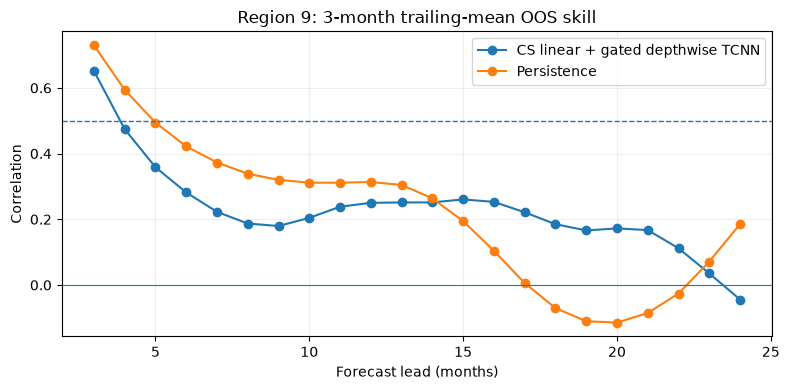

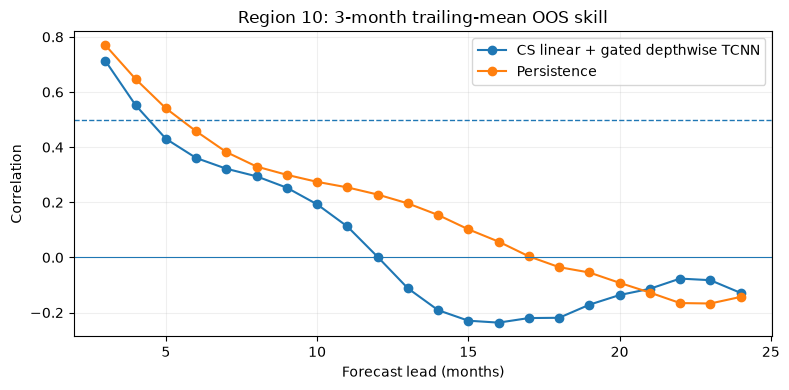

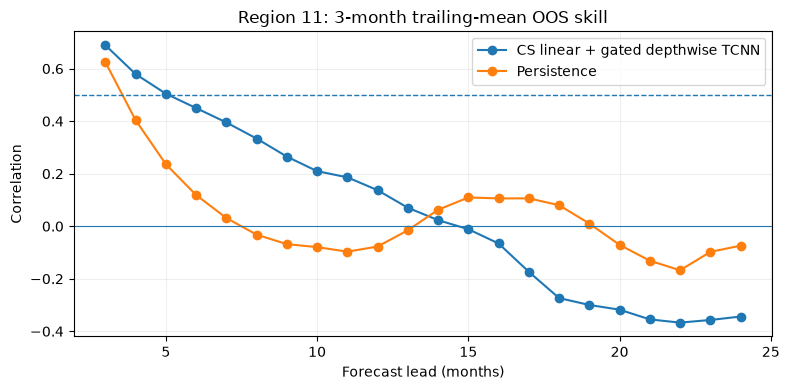

In [11]:
# ============================================================
# Standard plots
# ============================================================

plot_skill_curves()

# Optional diagnostics:
#
# plot_spaghetti_region(
#     region=9,
#     every=1,
#     start_date="2014-01-01",
#     end_date="2021-12-31",
# )
#
# plot_gate_summary(
#     region=9,
# )
#
# plot_amplitude_ratio()
#
# plot_training_loss_components(
#     region=9,
#     fold_id=4,
# )


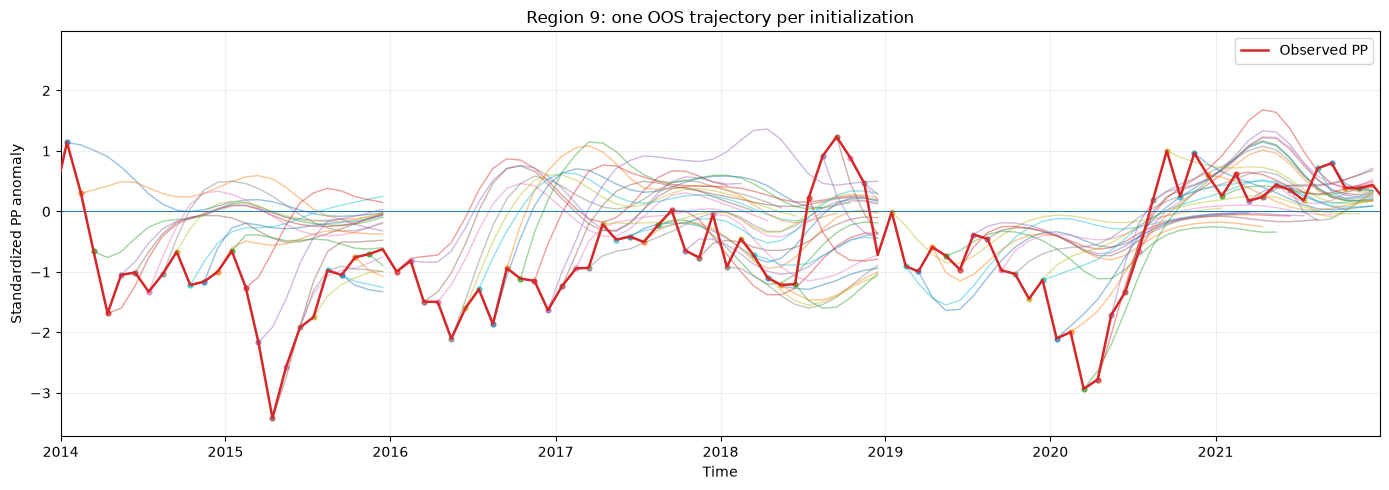

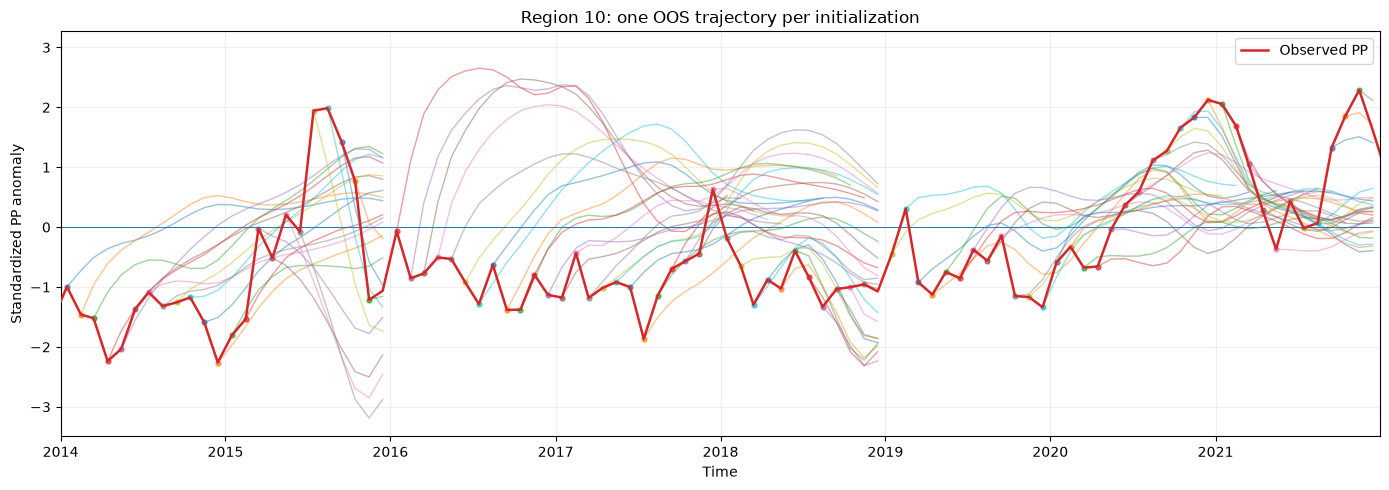

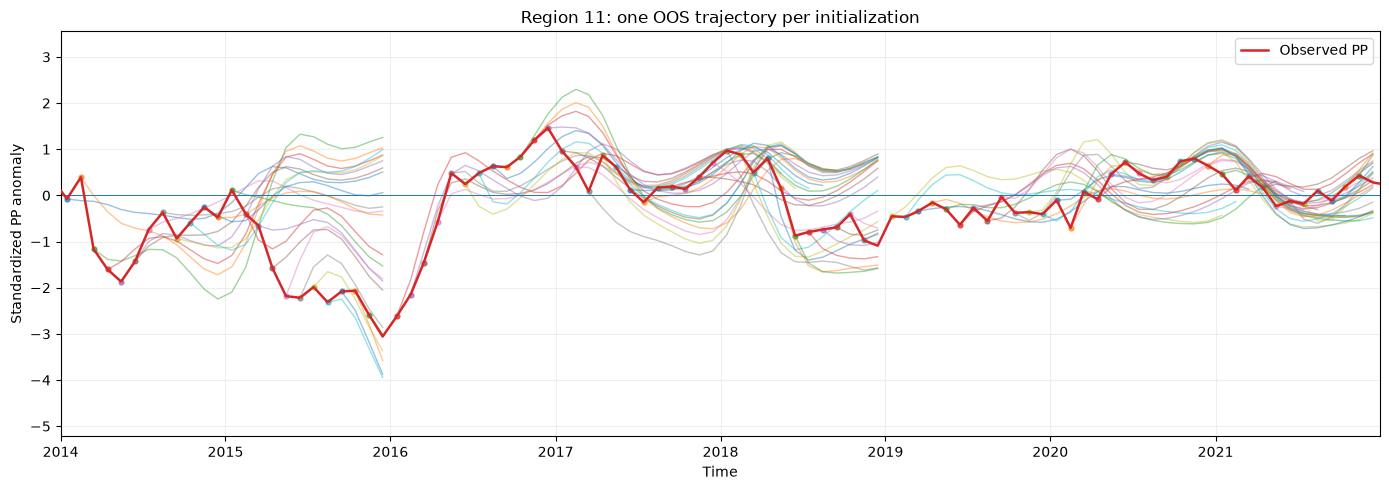

In [12]:
plot_spaghetti_region(
    region=9,
    every=1,
    start_date="2014-01-01",
    end_date="2021-12-31",
)
plot_spaghetti_region(
    region=10,
    every=1,
    start_date="2014-01-01",
    end_date="2021-12-31",
)
plot_spaghetti_region(
    region=11,
    every=1,
    start_date="2014-01-01",
    end_date="2021-12-31",
)

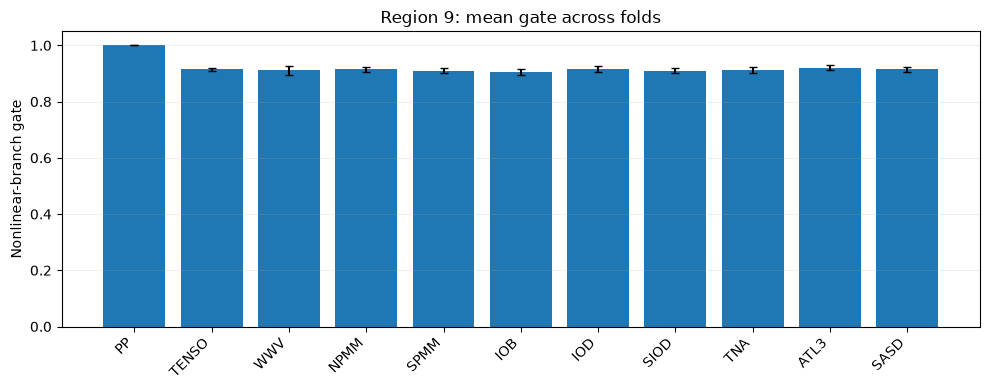

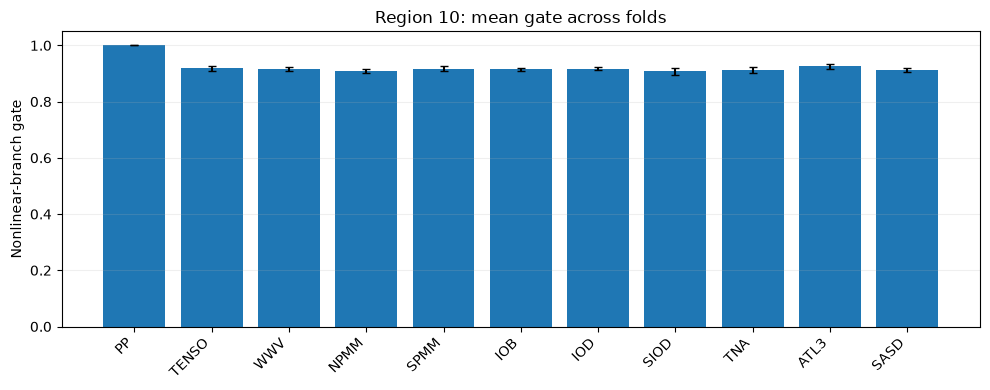

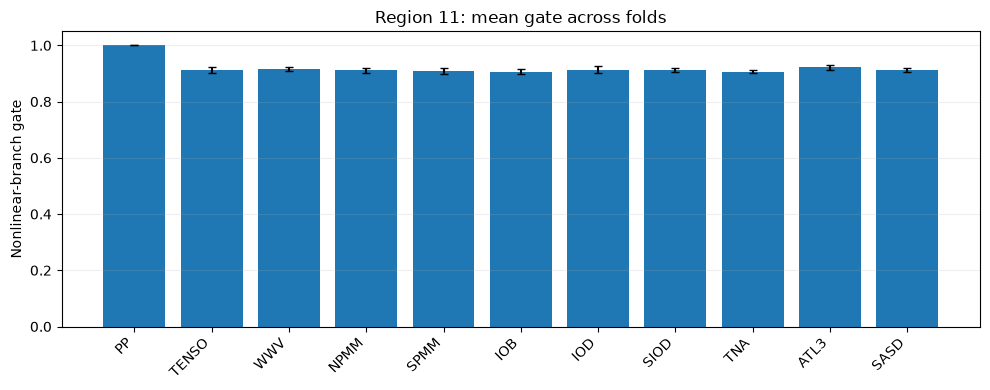

In [13]:
plot_gate_summary(
    region=9,
)
plot_gate_summary(
    region=10,
)
plot_gate_summary(
    region=11,
)



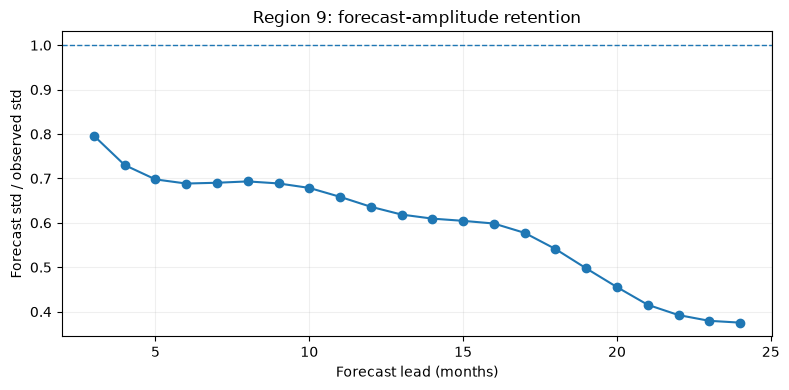

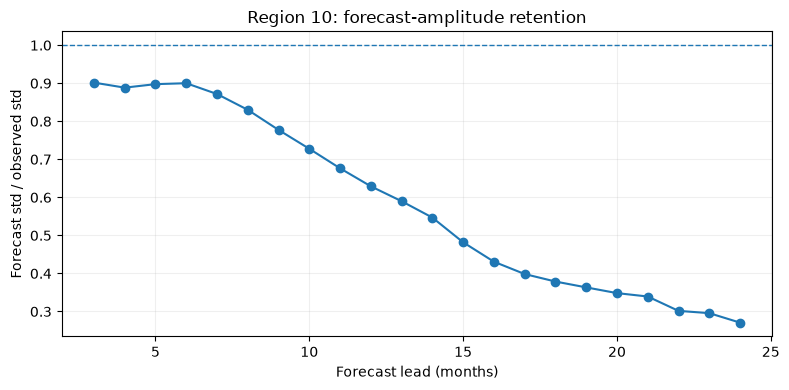

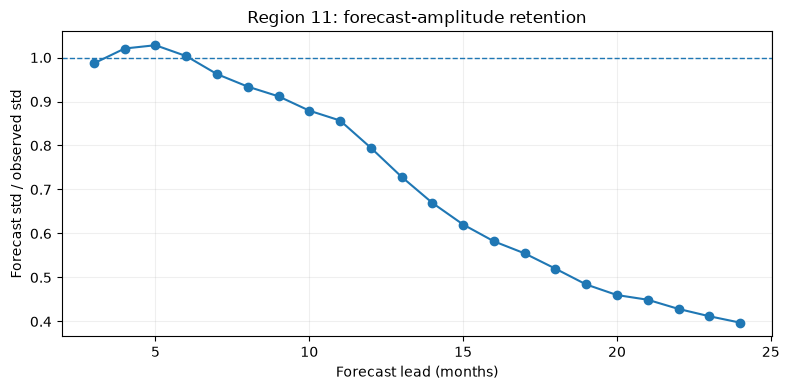

In [14]:


plot_amplitude_ratio()